In [7]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import load_model
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mobilenet_preprocess
import matplotlib.pyplot as plt

In [8]:
model = load_model(r"/Users/phandangvu/Desktop/DATCOM - AGRICULTURE /Model/Tomato_Leaf_Diseases_Model_0.0.1.keras")

In [9]:
test_path = '/Users/phandangvu/Desktop/DATCOM - AGRICULTURE /Tomato_Datasets/Dataset/test'

In [10]:
test_gen = ImageDataGenerator(preprocessing_function=mobilenet_preprocess)

test_data = test_gen.flow_from_directory(
    test_path,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

pred_prob = model.predict(test_data)
y_pred = np.argmax(pred_prob, axis=1)

true_labels = test_data.classes
class_names = list(test_data.class_indices.keys())
print(classification_report(true_labels, y_pred, target_names=class_names))

Found 14185 images belonging to 10 classes.


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


444/444 ━━━━━━━━━━━━━━━━━━━━ 66s 148ms/step
                          precision    recall  f1-score   support

          Bacterial spot       0.97      0.97      0.97      1594
            Early blight       0.89      0.94      0.91       979
                 Healthy       0.60      1.00      0.75      1378
             Late blight       0.98      0.95      0.96      1509
                    Mold       0.99      0.95      0.97      1134
            Mosaic virus       1.00      0.78      0.88       902
           Septoria spot       0.88      0.97      0.92      1461
             Target spot       0.94      0.62      0.75      1297
Two spotted spider mites       0.97      0.72      0.82      1404
            Yellow virus       0.99      0.99      0.99      2527

                accuracy                           0.90     14185
               macro avg       0.92      0.89      0.89     14185
            weighted avg       0.92      0.90      0.90     14185



Text(0.5, 58.7222222222222, 'Predicted Label')

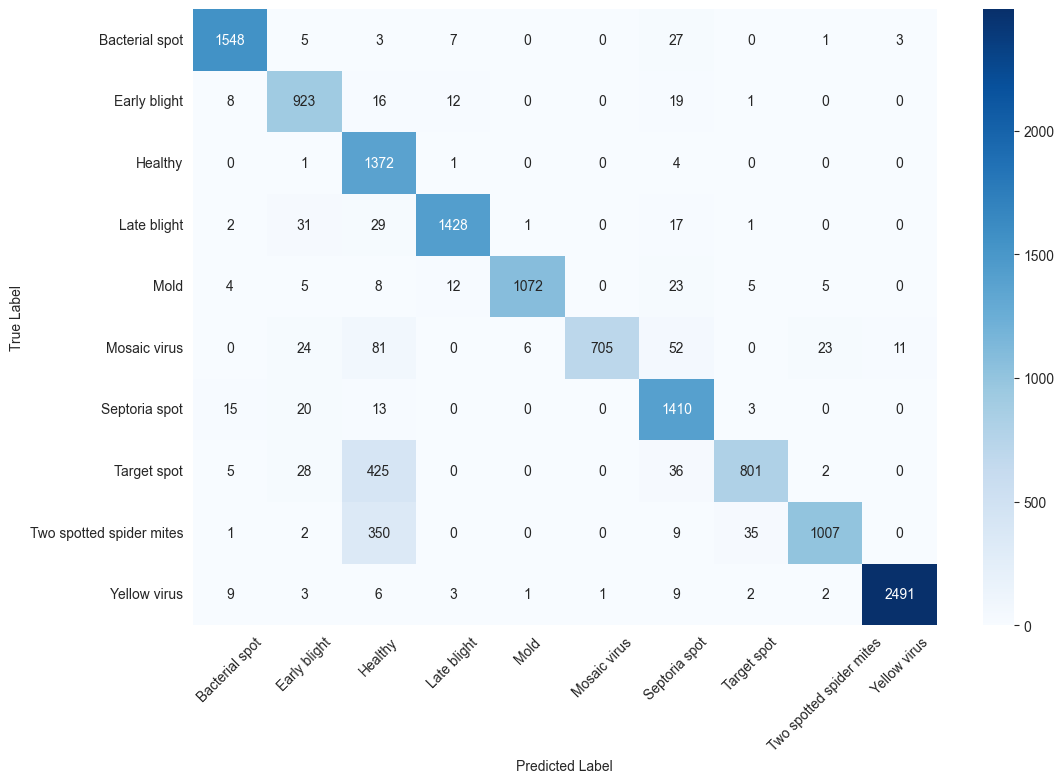

In [11]:
import seaborn as sns
plt.figure(figsize=(12, 8))
sns.heatmap(
    confusion_matrix(true_labels, y_pred),
    fmt='d', cmap='Blues',
    annot=True,
    xticklabels=class_names,
    yticklabels=class_names
)
plt.xticks(rotation=45)
plt.ylabel('True Label')
plt.xlabel('Predicted Label')

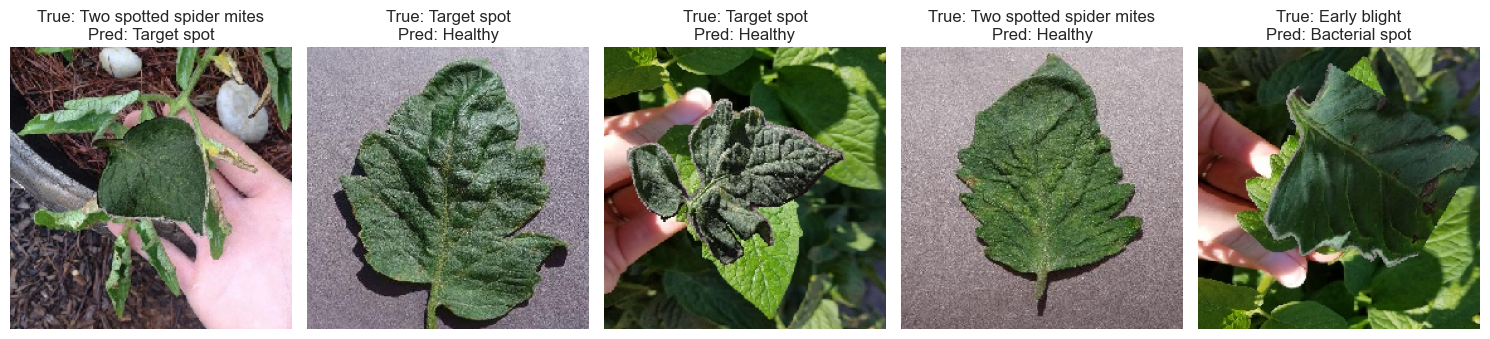

In [12]:
import random

misclassified_idx = np.where(true_labels != y_pred)[0]
random_wrong = np.random.choice(misclassified_idx, size=5, replace=False)

test_images, _ = next(iter(test_data))
test_images_all = []

for i in range(len(test_data)):
    imgs, _ = test_data[i]
    test_images_all.extend(imgs)

test_images_all = np.array(test_images_all)

plt.figure(figsize=(15, 5))

for i, idx in enumerate(random_wrong):
    plt.subplot(1, 5, i + 1)
    img_to_show = (test_images_all[idx] + 1) / 2.0
    plt.imshow(img_to_show)
    plt.axis('off')
    plt.title(f"True: {class_names[true_labels[idx]]}\nPred: {class_names[y_pred[idx]]}")

plt.tight_layout()
plt.show()